In [1]:
import pandas as pd

hospital_df = pd.read_csv("Medicare_Hospital_Spending_Per_Patient_-_Hospital.csv")
state_df = pd.read_csv("Medicare Hospital Spending per Patient - State.csv")
beneficiary_df = pd.read_csv("Medicare_hospital_spending_per_patient__Medicare_Spending_per_Beneficiary____Additional_Decimal_Places.csv")

In [2]:
print(hospital_df.shape)
print(state_df.shape)
print(beneficiary_df.shape)

(4818, 15)
(56, 7)
(3282, 6)


In [3]:
hospital_df.head()
state_df.head()
beneficiary_df.head()

,Provider,Measure_ID,Value,Footnote,Start_Date,End_Date
0,10001,MSPB-1,0.979005,NaN,1012014,12312014
1,10005,MSPB-1,0.975260,NaN,1012014,12312014
2,10006,MSPB-1,0.954461,NaN,1012014,12312014
3,10007,MSPB-1,1.065313,NaN,1012014,12312014
4,10008,MSPB-1,1.013882,NaN,1012014,12312014


In [4]:
hospital_df.info()
hospital_df.describe(include='object')
hospital_df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4818 entries, 0 to 4817
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Provider ID         4818 non-null   int64  
 1   Hospital Name       4818 non-null   object 
 2   Address             4818 non-null   object 
 3   City                4818 non-null   object 
 4   State               4818 non-null   object 
 5   ZIP Code            4818 non-null   int64  
 6   County Name         4803 non-null   object 
 7   Phone Number        4818 non-null   int64  
 8   Measure Name        4818 non-null   object 
 9   Measure ID          4818 non-null   object 
 10  Score               3172 non-null   float64
 11  Footnote            1646 non-null   object 
 12  Measure Start Date  4818 non-null   object 
 13  Measure End Date    4818 non-null   object 
 14  Location            4818 non-null   object 
dtypes: float64(1), int64(3), object(11)
memory usage: 564.7

Provider ID              0
Hospital Name            0
Address                  0
City                     0
State                    0
ZIP Code                 0
County Name             15
Phone Number             0
Measure Name             0
Measure ID               0
Score                 1646
Footnote              3172
Measure Start Date       0
Measure End Date         0
Location                 0
dtype: int64

### MISSING VALUE 

In [5]:
hospital_df = hospital_df.drop(columns=['Footnote'])

In [6]:
hospital_df['Score'].isnull().mean()*100

34.163553341635534

In [7]:
hospital_df['Score'].fillna(hospital_df['Score'].median(), inplace=True)

In [8]:
hospital_df['County Name'].fillna("Unknown", inplace=True)

The dataset contained missing values in the Score, Footnote and County Name columns. The Footnote column was removed due to excessive missing values and low analytical value. Missing values in Score were replaced using median imputation. County Name missing values were replaced with "Unknown".

In [9]:
hospital_df.duplicated().sum()

0

In [10]:
hospital_df['State'].unique()

array(['AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA', 'HI',
       'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MA', 'MI', 'MN', 'MS',
       'MO', 'NE', 'MT', 'NV', 'NJ', 'NM', 'NY', 'NC', 'ND', 'OH', 'SD',
       'VI', 'AS', 'GU', 'MP', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'TN',
       'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY', 'ID', 'DC', 'MD',
       'NH'], dtype=object)

In [11]:
hospital_df['Hospital Name'].unique()

array(['MARSHALL MEDICAL CENTER SOUTH', 'WEDOWEE HOSPITAL',
       'MIZELL MEMORIAL HOSPITAL', ..., 'EMERUS COMMUNITY HOSPITAL',
       'TEXAS HEALTH HARRIS METHODIST HOSPITAL ALLIANCE',
       'HOPEBRIDGE HOSPITAL'], dtype=object)

## Distribution Visualization

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\irzam\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


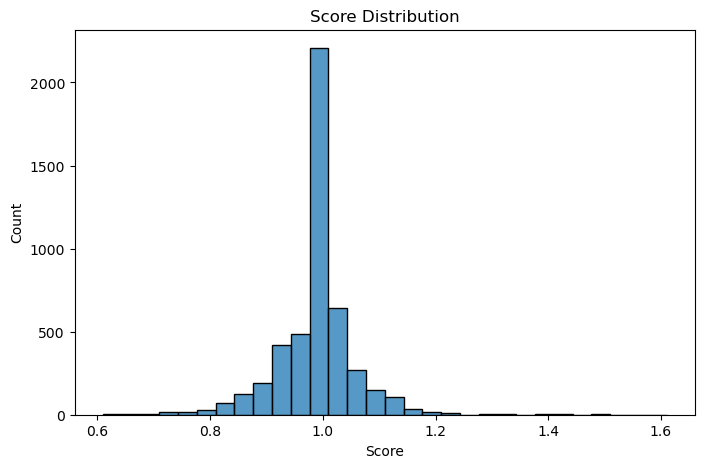

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(hospital_df['Score'], bins=30)
plt.title("Score Distribution")
plt.show()


## Boxplot (outlier detetction)

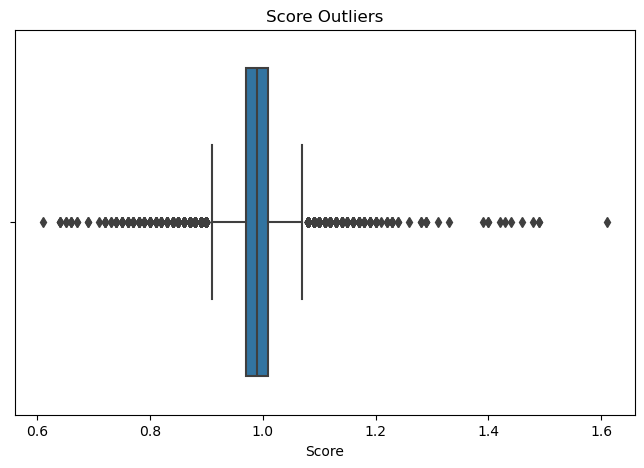

In [14]:
plt.figure(figsize=(8,5))

sns.boxplot(x=hospital_df['Score'])

plt.title("Score Outliers")

plt.show()

## State Comparison

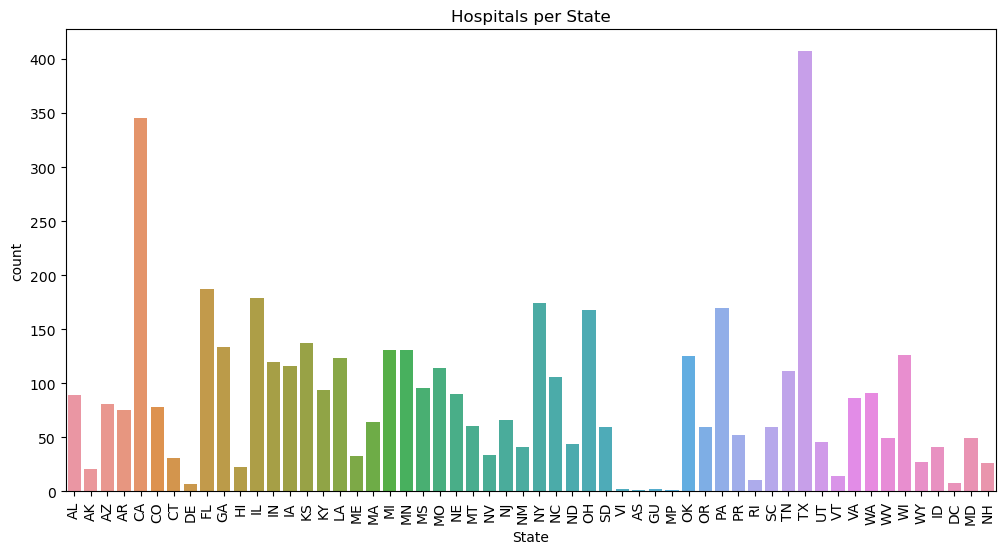

In [15]:
plt.figure(figsize=(12,6))

sns.countplot(x='State', data=hospital_df)

plt.xticks(rotation=90)

plt.title("Hospitals per State")

plt.show()

## Average score by state

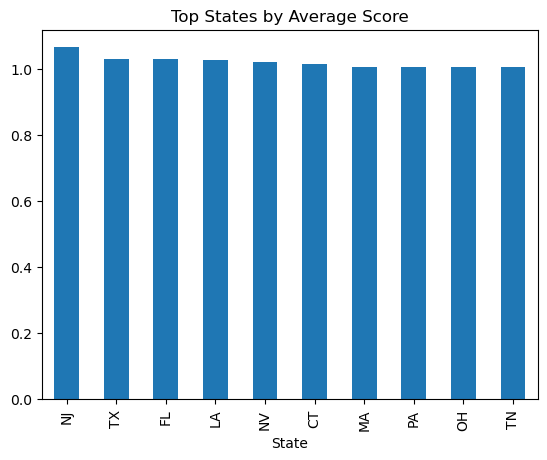

In [16]:
state_avg = hospital_df.groupby('State')['Score'].mean()
state_avg.sort_values(ascending=False).head(10)
state_avg.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top States by Average Score")

plt.show()

## Correlation Analysis

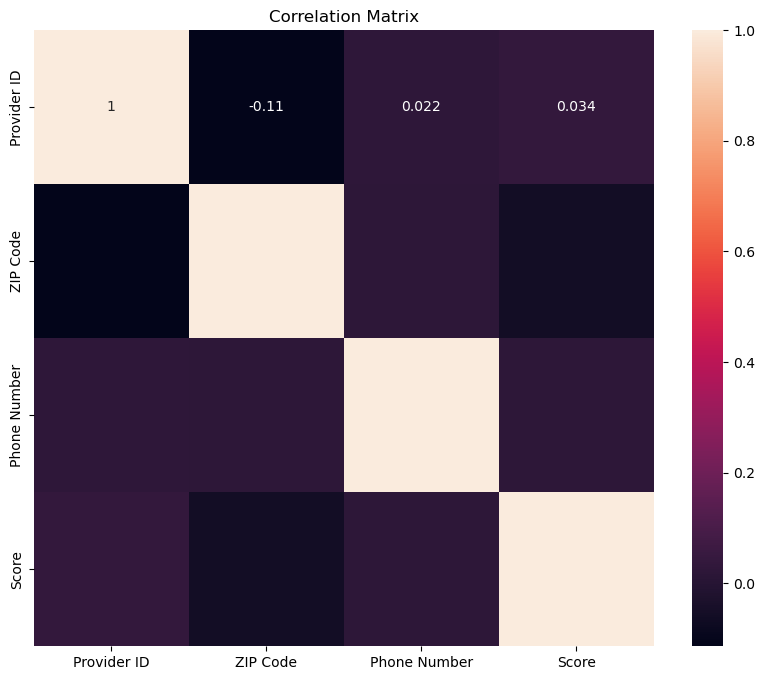

In [17]:
numeric = hospital_df.select_dtypes(include='number')
plt.figure(figsize=(10,8))

sns.heatmap(numeric.corr(), annot=True)

plt.title("Correlation Matrix")

plt.show()

## Time Analysis

In [18]:
hospital_df['Measure Start Date'] = pd.to_datetime(hospital_df['Measure Start Date'])
hospital_df['Measure End Date'] = pd.to_datetime(hospital_df['Measure End Date'])

In [19]:
hospital_df['duration'] = (
hospital_df['Measure End Date']
-
hospital_df['Measure Start Date']
).dt.days


In [20]:
hospital_df['duration'].describe()

count    4818.0
mean      364.0
std         0.0
min       364.0
25%       364.0
50%       364.0
75%       364.0
max       364.0
Name: duration, dtype: float64

In [21]:
hospital_df.groupby('State')['Score'].mean()

State
AK    0.940000
AL    0.981685
AR    0.984933
AS    0.990000
AZ    0.951728
CA    0.988551
CO    0.975128
CT    1.014516
DC    0.981250
DE    0.995714
FL    1.028128
GA    0.962761
GU    0.990000
HI    0.933478
IA    0.972500
ID    0.977561
IL    0.999218
IN    0.998833
KS    0.970584
KY    0.974362
LA    1.026992
MA    1.006094
MD    0.990000
ME    0.967879
MI    0.971679
MN    0.959160
MO    0.964912
MP    0.990000
MS    0.988958
MT    0.970984
NC    0.952453
ND    0.977727
NE    0.989778
NH    0.998462
NJ    1.065152
NM    0.912683
NV    1.020294
NY    0.979713
OH    1.005536
OK    0.957120
OR    0.933167
PA    1.005882
PR    0.990000
RI    0.983636
SC    0.970667
SD    0.964500
TN    1.004414
TX    1.030147
UT    0.977609
VA    0.958488
VI    0.990000
VT    0.976429
WA    0.961868
WI    0.960714
WV    0.970204
WY    0.964444
Name: Score, dtype: float64

In [22]:
hospital_df.groupby('County Name')['Score'].mean().head(10)

County Name
ABBEVILLE    0.990000
ACADIA       1.000000
ADA          0.916667
ADAIR        0.892500
ADAMS        0.996667
ADDISON      0.990000
AGUADILLA    0.990000
AIBONITO     0.990000
AIKEN        1.020000
AITKIN       0.990000
Name: Score, dtype: float64

## Top Hospitals

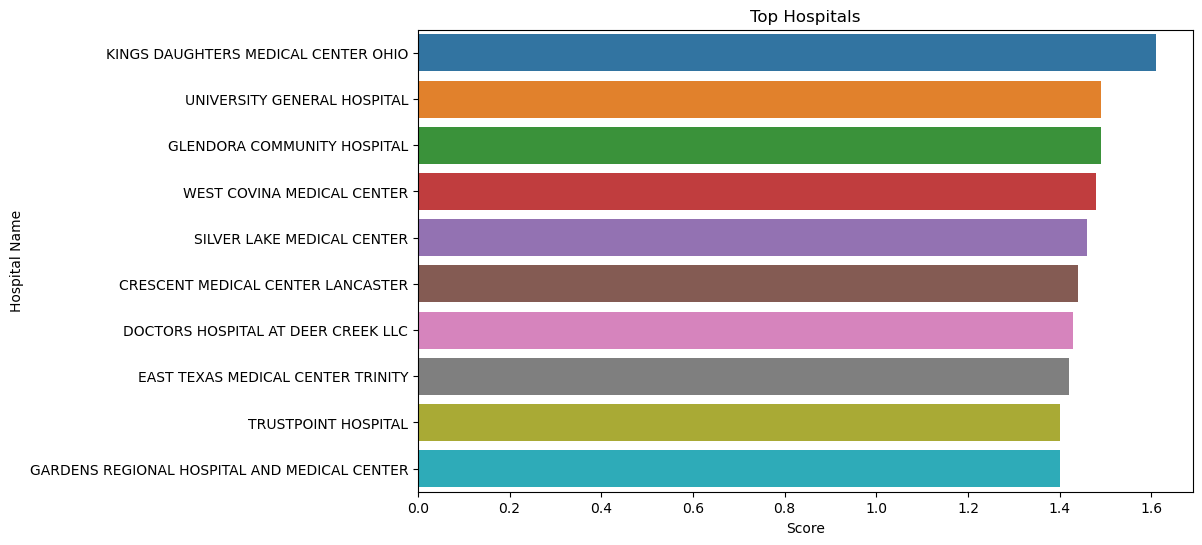

In [23]:
top = hospital_df.sort_values(by='Score', ascending=False).head(10)

plt.figure(figsize=(10,6))

sns.barplot(
x='Score',
y='Hospital Name',
data=top
)

plt.title("Top Hospitals")

plt.show()

## EDA Conclusion:
The exploratory data analysis revealed several important characteristics of the dataset. The dataset contains hospital spending information across different states and providers with minimal missing data. The Footnote column was removed due to excessive missing values and low analytical importance. Missing values in the Score column were handled using median imputation while County Name missing values were replaced with "Unknown".

The distribution of hospital scores shows moderate variation with some hospitals appearing as high-cost outliers. State-level analysis indicates variation in healthcare spending patterns across regions. Correlation analysis showed limited strong relationships between numeric variables, suggesting multiple independent factors influence hospital spending.

Time analysis showed consistent measurement periods across hospitals, allowing reliable comparison. Group analysis further revealed differences in average scores between states and counties.

Overall, the dataset is suitable for predictive modeling due to:

Low missing data after cleaning
Presence of meaningful numeric variables
Geographic features for segmentation
Time features for analysis
Sufficient size for machine learning

This analysis supports proceeding to feature engineering and predictive modeling.

## Target Selection:
Target = score

The target variable selected for prediction is the hospital Score. This score reflects hospital spending performance and allows prediction of healthcare cost efficiency based on hospital characteristics.


## Feature Engineering

In [30]:
df = hospital_df.copy()

In [33]:
df = df.drop(columns=[
    'Hospital Name',
    'Address',
    'City',
    'Phone Number',
    'Location',
    'Footnote'
], errors='ignore')

# fill missing values
if 'Score' in df.columns:
    df['Score'] = df['Score'].fillna(df['Score'].median())
if 'County Name' in df.columns:
    df['County Name'] = df['County Name'].fillna('Unknown')

# convert dates if present
for col in ['Measure Start Date', 'Measure End Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

if 'Measure Start Date' in df.columns and 'Measure End Date' in df.columns:
    df['duration'] = (df['Measure End Date'] - df['Measure Start Date']).dt.days
    df = df.drop(columns=['Measure Start Date', 'Measure End Date'])



In [34]:
#convert categorical
X = df.drop(columns=['Score'])
X = pd.get_dummies(X, drop_first=True)

y = df['Score']


## Model Development

In [36]:
#split data
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# quick check
print(X_train.select_dtypes(include='object').columns)

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)
print("Model trained successfully")

Index([], dtype='object')
Model trained successfully


In [28]:
X_train.dtypes

City                          object
ZIP Code                       int64
Measure Name                  object
Measure ID                    object
Measure Start Date    datetime64[ns]
                           ...      
County Name_YOLO                bool
County Name_YORK                bool
County Name_YOUNG               bool
County Name_YUBA                bool
County Name_YUMA                bool
Length: 1629, dtype: object

In [37]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

print("MAE:",mean_absolute_error(y_test,pred))
print("R2:",r2_score(y_test,pred))

MAE: 0.04201306502338159
R2: 0.0025850129867113214


## Explainability(SHAP)

In [38]:
!pip install shap

INFO: pip is looking at multiple versions of pandas to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/554.9 kB ? eta -:--:--
   -- ------------------------------------- 30.7/554.9 kB ? eta -:--:--
   -- ------------------------------------ 41.0/554.9 kB 653.6 kB/s eta 0:00:01
   -- ------------------------------------ 41.0/554.9 kB 653.6 kB/s eta 0:00:01
   -- ------------------------------------ 41.0/554.9 kB 653.6 kB/s eta 0:00:01
   -- ------------------------------------ 41.0/554.9 kB 653.6 kB/s eta 0:00:01
   -- ------------------------------------ 41.0/554.9 kB 653.6 kB/s eta 0:00:01
   ------- ------------------------------ 102.4/554.9 kB 346.5 kB/s eta 0:00:02
   ------- ------------------------------ 102.4/554.9 kB 346.5 kB/s eta 0:00:02
   ------- ------------------------------ 102.4/554.9 kB 346.5 kB/s eta 0:00:02
   ------- ------------------------------ 102.4/554.9 kB 346.5 kB/s eta 0:

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.0 requires FuzzyTM>=0.4.0, which is not installed.
astropy 5.3.4 requires numpy<2,>=1.21, but you have numpy 2.4.4 which is incompatible.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.4.4 which is incompatible.
matplotlib 3.8.0 requires numpy<2,>=1.21, but you have numpy 2.4.4 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.4.4 which is incompatible.
streamlit 1.30.0 requires numpy<2,>=1.19.3, but you have numpy 2.4.4 which is incompatible.
streamlit 1.30.0 requires pandas<3,>=1.3.0, but you have pandas 3.0.1 which is incompatible.
streamlit 1.30.0 requires protobuf<5,>=3.20, but you have protobuf 6.33.2 which is incompatible.
streamlit 1.30.0 requires tenacity<9,>=8.1.0, but you have tenacity 9.1.2 which is incompatible.


In [39]:
import shap

In [ ]:
explainer= shap.TreeExplainer(model)
shap_values=explainer.shap_values(X_test)